In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.signal import find_peaks
import datetime
%matplotlib inline

In [ ]:
#load data

data_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data'
eva_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\EVA'

df_wind = pd.read_csv(data_dir + r'\wind_data_sines_2010_2020.csv', index_col=0, parse_dates=True)

print(df_wind.head())
print(f"\nTotal records: {len(df_wind)}")
print(f"Time range: {df_wind.index[0]} to {df_wind.index[-1]}")
print(f"\nWind speed 100m stats:")
print(df_wind['wind_speed_100m_ms'].describe())

                     wind_speed_10m_ms  wind_dir_10m_deg  wind_speed_100m_ms  \
2010-01-01 00:00:00          11.378973         274.83020           13.204857   
2010-01-01 03:00:00          12.063279         277.67377           14.090853   
2010-01-01 06:00:00          12.025712         283.16943           14.135208   
2010-01-01 09:00:00          11.216561         287.58440           13.078920   
2010-01-01 12:00:00           9.727643         286.97310           11.236833   

                     wind_dir_100m_deg  
2010-01-01 00:00:00          274.92224  
2010-01-01 03:00:00          277.74454  
2010-01-01 06:00:00          282.98193  
2010-01-01 09:00:00          287.57388  
2010-01-01 12:00:00          287.26285  

Total records: 29224
Time range: 2010-01-01 00:00:00 to 2020-12-31 21:00:00

Wind speed 100m stats:
count    29224.000000
mean         7.273681
std          3.451358
min          0.012559
25%          4.692955
50%          7.019224
75%          9.561872
max         23.391

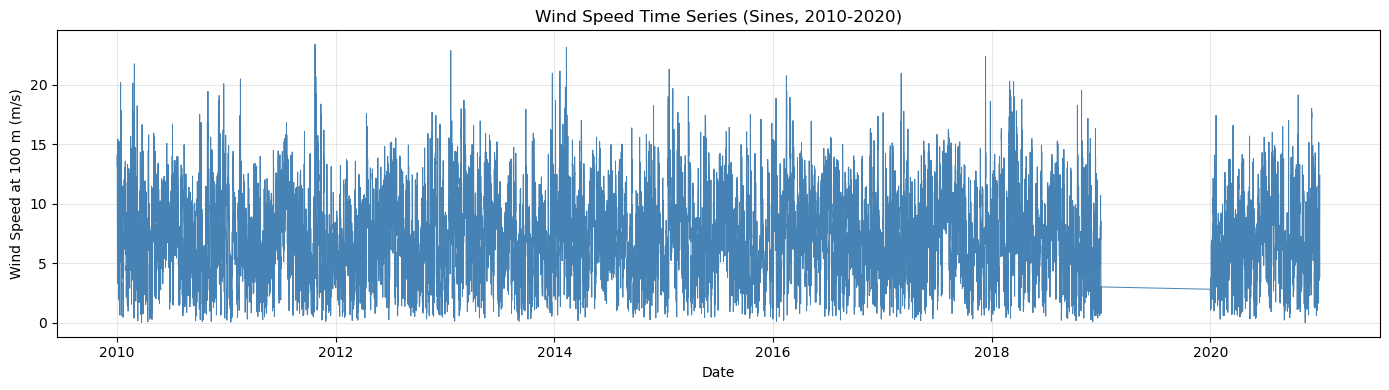

In [3]:
#time series plot 
plt.figure(figsize=(14, 4))
plt.plot(df_wind.index, df_wind['wind_speed_100m_ms'], color='steelblue', linewidth=0.7)
plt.xlabel('Date')
plt.ylabel('Wind Speed at 100 m (m/s)')
plt.title('Wind Speed Time Series (Sines, 2010-2020)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(eva_dir + r'\wind_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

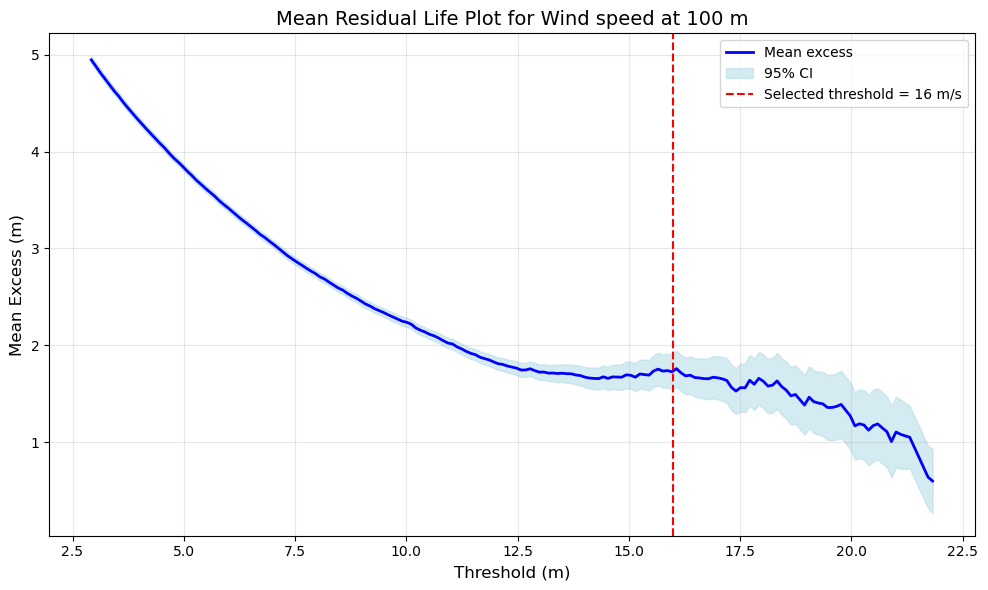

In [16]:
#MRL plot 
def mrl_plot(data, threshold_range=None):

    if threshold_range is None:
        threshold_range = np.linspace(data.quantile(0.10), data.max() * 0.999, 200)

    mean_excesses =[]
    ci_upper = []
    ci_lower = []

    for th in threshold_range:
        excesses = data[data > th] - th
        if len(excesses)<10:
            break
        me = excesses.mean()
        se= excesses.std() / np.sqrt(len(excesses))
        
        mean_excesses.append(me)
        ci_upper.append(me + 1.96*se)
        ci_lower.append(me - 1.96*se)
        
    th_plot = threshold_range[:len(mean_excesses)]

    plt.figure(figsize=(10, 6))
    plt.plot(th_plot, mean_excesses, 'b', linewidth=2, label='Mean excess')
    plt.fill_between(th_plot, ci_lower, ci_upper, color='lightblue', alpha=0.5, label='95% CI')
    plt.xlabel('Threshold (m)', fontsize=12)
    plt.ylabel('Mean Excess (m)', fontsize=12)
    plt.title('Mean Residual Life Plot for Wind speed at 100 m', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.axvline(16, color='red', linestyle='--', linewidth=1.5, label='Selected threshold = 16 m/s')
    plt.legend()
    plt.tight_layout()
    plt.savefig(r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\EVA\wind100_mrl.png', dpi=300, bbox_inches='tight')
    plt.show()
    return th_plot, mean_excesses

th_range, me = mrl_plot(df_wind['wind_speed_100m_ms'])


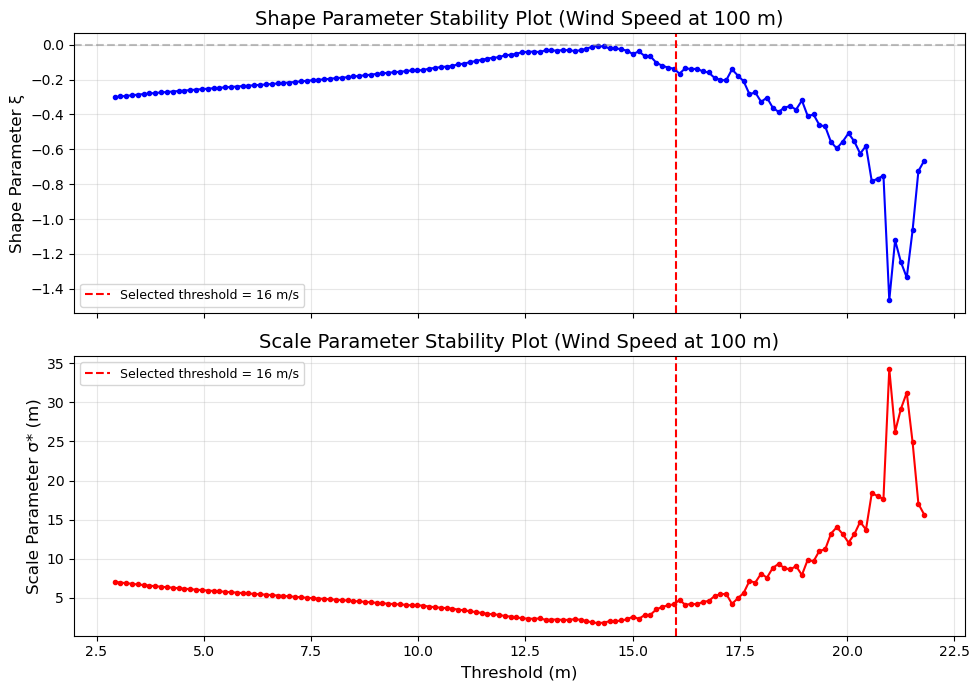

In [17]:
def parameter_stability_plot(data, threshold_range=None):
    
    if threshold_range is None:
        threshold_range = np.linspace(data.quantile(0.10), data.max() * 0.99, 150)
    
    shapes = []
    scales_star = []
    th_valid = []

    for th in threshold_range:
        excesses = data[data > th] - th
        if len(excesses) < 10:
            break
        try: 
            xi, loc, sigma = stats.genpareto.fit(excesses, floc=0)
            sigma_star = sigma - xi *th
            shapes.append(xi)
            scales_star.append(sigma_star)
            th_valid.append(th)
        except:
            continue

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    ax1.plot(th_valid, shapes, 'b-o', markersize=3)
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax1.set_ylabel('Shape Parameter ξ', fontsize=12)
    ax1.set_title('Shape Parameter Stability Plot (Wind Speed at 100 m)', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.axvline(16, color='red', linestyle='--', linewidth=1.5, label='Selected threshold = 16 m/s')
    ax1.legend(fontsize=9)

    ax2.plot(th_valid, scales_star, 'r-o', markersize=3)
    ax2.set_xlabel('Threshold (m)', fontsize=12)    
    ax2.set_ylabel('Scale Parameter σ* (m)', fontsize=12)
    ax2.set_title('Scale Parameter Stability Plot (Wind Speed at 100 m)', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.axvline(16, color='red', linestyle='--', linewidth=1.5, label='Selected threshold = 16 m/s')
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\EVA\wind100_parameter_stability.png', dpi=300, bbox_inches='tight')
    plt.show()

parameter_stability_plot(df_wind['wind_speed_100m_ms'])

curve MRL flats around 12 and  17 m/s
parameters: stable between 3 and 15 m/s 


In [6]:
u100 = df_wind['wind_speed_100m_ms'].values
time_wind = df_wind.index
n_years = 10 
dl = 72
dl_steps = int (dl / 3) 

print("Threshold sensitivity check:")
print(f"{'Threshold':>12} {'N peaks':>10} {'peaks/year':>12}")
print("-" * 36)

for th_test in np.arange(10,22,1):
    peaks_test, _ = find_peaks(u100, height=th_test, distance = dl_steps)
    print(f"{th_test:>10.1f} m/s  {len(peaks_test):>8}  "
          f"{len(peaks_test)/n_years:>10.1f}")

Threshold sensitivity check:
   Threshold    N peaks   peaks/year
------------------------------------
      10.0 m/s       590        59.0
      11.0 m/s       512        51.2
      12.0 m/s       429        42.9
      13.0 m/s       323        32.3
      14.0 m/s       224        22.4
      15.0 m/s       145        14.5
      16.0 m/s        87         8.7
      17.0 m/s        55         5.5
      18.0 m/s        37         3.7
      19.0 m/s        25         2.5
      20.0 m/s        16         1.6
      21.0 m/s         7         0.7


Threshold: 16 m
Declustering window: 72 hours (24 steps)
Number of peaks identified: 87
Average peaks per year: 8.70


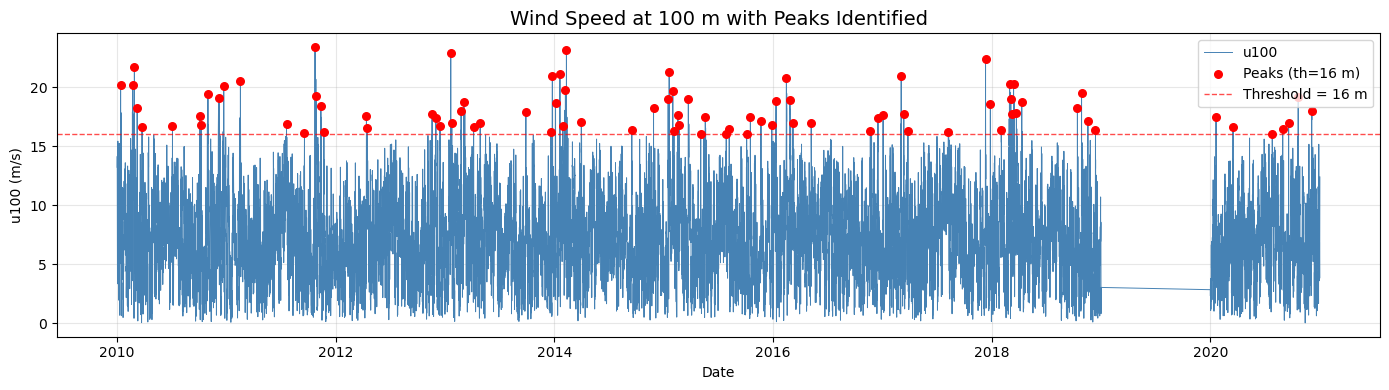

Excess statistics:
Mean excess: 2.166 m
max excess: 7.392 m
min excess: 0.006 m


In [10]:
# POT parameters 
th = 16
dl = 72  
n_years = 10 

dl_steps = int(dl /3)  #we have 3-hourly data 

u100 = df_wind['wind_speed_100m_ms'].values
time = df_wind.index

peak_indices, _ = find_peaks(u100, height=th, distance = dl_steps)
peak_values = u100[peak_indices]
peak_times = time[peak_indices]
lambda_hat= len(peak_values) / n_years
print(f"Threshold: {th} m")
print(f"Declustering window: {dl} hours ({dl_steps} steps)")
print(f"Number of peaks identified: {len(peak_values)}")
print(f"Average peaks per year: {len(peak_values)/n_years:.2f}")

plt.figure(figsize=(14, 4))
plt.plot(time_wind, u100, color='steelblue', linewidth=0.7, label='u100')
plt.scatter(peak_times, peak_values, color='red', s=30, zorder=5, label=f'Peaks (th={th} m)')
plt.axhline(th, color='red', linestyle='--', linewidth=1, alpha=0.7,label=f'Threshold = {th} m')
plt.xlabel('Date')
plt.ylabel('u100 (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Wind Speed at 100 m with Peaks Identified', fontsize=14)
plt.tight_layout()
plt.savefig(r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\EVA\wind100_peaks.png', dpi=300, bbox_inches='tight')
plt.show()

excesses = peak_values - th
print(f"Excess statistics:") 
print(f"Mean excess: {excesses.mean():.3f} m")
print(f"max excess: {excesses.max():.3f} m")   
print(f"min excess: {excesses.min():.3f} m")


GPD parameters:
Shape, ξ: -0.276
Location, μ: 0.000
Scale, σ: 2.785

 ξ < 0 → Bounded Weibull tail (upper bound exists)
Upper bound: 26.082 m


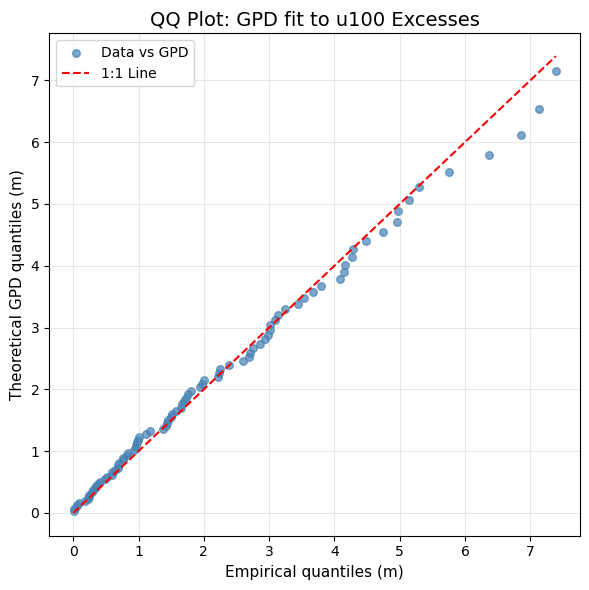

In [11]:
xi, loc, sigma = stats.genpareto.fit(excesses, floc=0)

print(f"\nGPD parameters:")
print(f"Shape, ξ: {xi:.3f}")
print(f"Location, μ: {loc:.3f}")
print(f"Scale, σ: {sigma:.3f}")

#shape parameter 
if xi <0: 
    print(f"\n ξ < 0 → Bounded Weibull tail (upper bound exists)")
    upper_bound = th - sigma/xi
    print(f"Upper bound: {upper_bound:.3f} m")
elif xi == 0:
    print(f"\n ξ = 0 → Exponential tail")
else:
    print(f"\n ξ > 0 → Heavy Fréchet tail (no upper bound)")


#qq plot
n = len(excesses)
sorted_excesses = np.sort(excesses)
empirical_probs = np.arange (1, n+1) / (n+1)
theoretical_quantiles = stats.genpareto.ppf(empirical_probs, c=xi, loc=loc, scale=sigma)

plt.figure(figsize=(6,6))
plt.scatter(sorted_excesses, theoretical_quantiles, color='steelblue', s=30, alpha=0.7, label = 'Data vs GPD')
max_val = max(sorted_excesses.max(), theoretical_quantiles.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='1:1 Line')
plt.xlabel('Empirical quantiles (m)', fontsize=11)
plt.ylabel('Theoretical GPD quantiles (m)', fontsize=11)
plt.title('QQ Plot: GPD fit to u100 Excesses', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\EVA\u100_gpd_qq.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
lambda_hat = len(peak_values) / n_years
print(f"lambda: {lambda_hat:.3f} peaks/year")

return_periods = [1, 10, 50, 100, 200, 475]


print(f"\nReturn levels (u100):")
print(f"{'Return Period':>15} {'u100 (m)':>10}")
print("-" * 28)

for TR in return_periods:
    if xi != 0:
        x_TR = th + (sigma / xi) * ((lambda_hat * TR)**xi - 1)
    else:
        x_TR = th + sigma * np.log(lambda_hat * TR)
    print(f"{TR:>12} yr  {x_TR:>8.2f} m")


lambda: 8.700 peaks/year

Return levels (u100):
  Return Period   u100 (m)
----------------------------
           1 yr     20.53 m
          10 yr     23.15 m
          50 yr     24.20 m
         100 yr     24.53 m
         200 yr     24.80 m
         475 yr     25.07 m


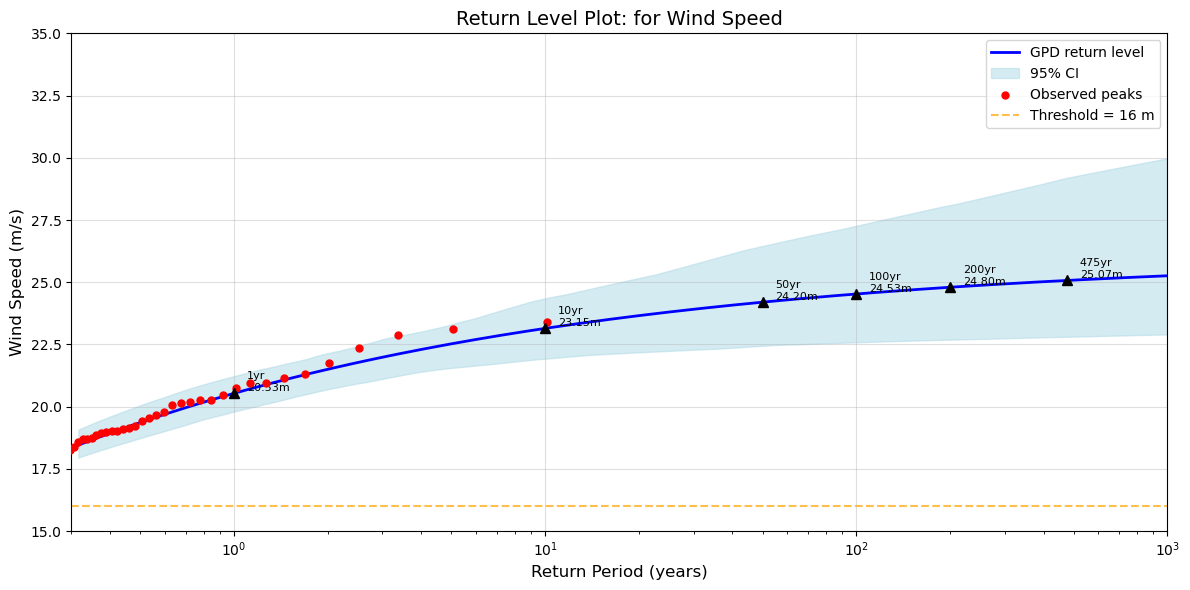


  Return Period Wind Speed (m/s)    95% CI lower    95% CI upper
----------------------------------------------------------
           1 yr     20.53 m         19.81 m         21.24 m
          10 yr     23.15 m         21.93 m         24.35 m
          50 yr     24.20 m         22.45 m         26.46 m
         100 yr     24.53 m         22.59 m         27.28 m
         200 yr     24.80 m         22.69 m         28.09 m
         475 yr     25.07 m         22.81 m         29.18 m


In [15]:

n_bootstrap = 500 
TR_range = np.logspace(-0.5, 3, 300)
wind_boot = np.zeros((n_bootstrap, len(TR_range)))

n_peaks = len(peak_values)
np.random.seed(42) 
for i in range(n_bootstrap):
    boot_exc = np.random.choice(excesses, size = len(excesses), replace=True)
    try: 
        xi_b, _, sigma_b = stats.genpareto.fit(boot_exc, floc=0)
        if xi_b != 0:
            wind_boot[i] = th + (sigma_b / xi_b) * ((lambda_hat * TR_range)**xi_b - 1)
        else:
            wind_boot[i] = th + sigma_b * np.log(lambda_hat * TR_range)
    except:
        wind_boot[i] = np.nan

if xi != 0:
    wind_return = th + (sigma / xi) * ((lambda_hat * TR_range)**xi - 1)
else:
    wind_return = th + sigma * np.log(lambda_hat * TR_range)

#95% confidence intervals
ci_low = np.nanpercentile(wind_boot, 2.5, axis=0)
ci_high = np.nanpercentile(wind_boot, 97.5, axis=0)

sorted_peaks = np.sort(peak_values)
emp_probs = np.arange(1, n_peaks+1) / (n_peaks + 1)
emp_TR = 1 / (lambda_hat * (1 - emp_probs))

plt.figure(figsize=(12, 6))
plt.semilogx(TR_range, wind_return, 'b-', linewidth=2, label='GPD return level')
plt.fill_between(TR_range, ci_low, ci_high, color='lightblue', alpha=0.5, label='95% CI')
plt.scatter(emp_TR, sorted_peaks, color='red', s=25, zorder=5, label='Observed peaks')
plt.axhline(th, color='orange', linestyle='--', alpha=0.7, label=f'Threshold = {th} m')

for TR in return_periods:
    if xi != 0:
        x_TR = th + (sigma / xi) * ((lambda_hat * TR)**xi - 1)
    else:
        x_TR = th + sigma * np.log(lambda_hat * TR)
    plt.plot(TR, x_TR, 'k^', markersize=7, zorder=6)
    plt.annotate(f'{TR}yr\n{x_TR:.2f}m', 
                 xy=(TR, x_TR), xytext=(TR*1.1, x_TR+0.1), fontsize=8)

plt.xlim([0.3, 1000])
plt.ylim([15, 35])
plt.xlabel('Return Period (years)', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12) 
plt.title('Return Level Plot: for Wind Speed', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\EVA\u100_return_period.png', dpi=300, bbox_inches='tight')
plt.show()


# Final table with CI
print(f"\n{'Return Period':>15} {'Wind Speed (m/s)':>15} {'95% CI lower':>15} {'95% CI upper':>15}")
print("-" * 58)
for TR in return_periods:
    if xi != 0:
        x_TR = th + (sigma / xi) * ((lambda_hat * TR)**xi - 1)
    else:
        x_TR = th + sigma * np.log(lambda_hat * TR)
    idx    = np.argmin(np.abs(TR_range - TR))
    x_low  = ci_low[idx]
    x_high = ci_high[idx]
    print(f"{TR:>12} yr  {x_TR:>8.2f} m  {x_low:>12.2f} m  {x_high:>12.2f} m")

In [14]:

print("\n=== Wind data quality check ===")
print(f"Missing values: {df_wind['wind_speed_100m_ms'].isna().sum()}")
print(f"Negative values: {(df_wind['wind_speed_100m_ms'] < 0).sum()}")
print(f"Values > 50 m/s (physically unrealistic): {(df_wind['wind_speed_100m_ms'] > 50).sum()}")


=== Wind data quality check ===
Missing values: 0
Negative values: 0
Values > 50 m/s (physically unrealistic): 0
